# **Phase 2: Logistic Regression Credit Risk Modeling**

This notebook implements the **Logistic Regression** portion of our corporate default prediction analysis. In credit risk modeling, logistic regression is the industry standard baseline due to its high interpretability. It models the probability of default as a function of key financial characteristics: 

$$\Pr(Y_{i,t+1} = 1 \mid X_{i,t}) = \frac{1}{1 + e^{-(\beta_0 + \beta' X_{i,t})}}$$

### **Notebook Highlights**
1. **Data Prep & Temporal Splitting**: Prepares the Kaggle U.S. Company Bankruptcy dataset and splits it chronologically: Train (1999–2011), Validation (2012–2014), and Test (2015–2018).
2. **Winsorization**: Clips features at the 1st and 99th percentiles using training set parameters to protect the model from denominator-induced financial ratio outliers.
3. **Baseline Logistic Regression**: Fits an interpretable 6-variable model based on credit risk theory (Profitability, Leverage, Size, Liquidity, Market Valuation).
4. **Regularized LASSO Logistic Regression**: Performs L1 penalization to automatically select variables across all 15 financial ratios and optimizes the regularizer $C$ on validation data.
5. **Advanced Evaluation**: Calculates ROC-AUC, PR-AUC, Confusion Matrices, and performs a **Top-Risk Bucket Recall** analysis (top 5% and 10% risk brackets).

In [1]:
# ── Standard Library & Data Science Tools ───────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlcroissant as mlc
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn: Preprocessing & Model Selection ──────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

## **1. Data Loading & Cleaning**
We load the dataset using `mlcroissant` and map the target variable: `b'failed'` is mapped to `1` (bankrupt in the next year) and `b'alive'` to `0`.

In [2]:
print("Loading dataset via mlcroissant...")
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/croissant/download')
record_sets = croissant_dataset.metadata.record_sets
df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))

# Clean column names
df.columns = df.columns.str.replace('american_bankruptcy.csv/', '')

# Rename variables to descriptive names
column_mapping = {
    'X1': 'current_assets',
    'X2': 'cost_of_goods_sold',
    'X3': 'depreciation_amortization',
    'X4': 'ebitda',
    'X5': 'inventory',
    'X6': 'net_income',
    'X7': 'total_receivables',
    'X8': 'market_value',
    'X9': 'net_sales',
    'X10': 'total_assets',
    'X11': 'total_longterm_debt',
    'X12': 'ebit',
    'X13': 'gross_profit',
    'X14': 'total_current_liabilities',
    'X15': 'retained_earnings',
    'X16': 'total_revenue',
    'X17': 'total_liabilities',
    'X18': 'total_operating_expenses'
}
df = df.rename(columns=column_mapping)

# Decode bytes to strings
df['company_name'] = df['company_name'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))
df['status_label'] = df['status_label'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

# Create target variable
df['target'] = df['status_label'].map({'failed': 1, 'alive': 0})
print(f"Target distribution:\n{df['target'].value_counts()}")

Loading dataset via mlcroissant...


  -  [Metadata(US Company Bankruptcy Prediction Dataset)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


Target distribution:
target
0    73462
1     5220
Name: count, dtype: int64


## **2. Feature Engineering**
We calculate the 15 standard financial ratios along with a size metric (log of total assets).

In [3]:
# Add size metric
df['log_total_assets'] = np.log(df['total_assets'].clip(lower=1e-5))

# Liquidity Ratios
df['current_ratio'] = df['current_assets'] / df['total_current_liabilities'].replace(0, float('nan'))
df['working_capital_to_assets'] = (df['current_assets'] - df['total_current_liabilities']) / df['total_assets'].replace(0, float('nan'))

# Profitability Ratios
df['roa'] = df['net_income'] / df['total_assets'].replace(0, float('nan'))
df['ebitda_margin'] = df['ebitda'] / df['total_revenue'].replace(0, float('nan'))
df['gross_margin'] = df['gross_profit'] / df['total_revenue'].replace(0, float('nan'))
df['ebit_margin'] = df['ebit'] / df['total_revenue'].replace(0, float('nan'))
df['retained_earnings_to_assets'] = df['retained_earnings'] / df['total_assets'].replace(0, float('nan'))

# Leverage Ratios
df['debt_ratio'] = df['total_liabilities'] / df['total_assets'].replace(0, float('nan'))
df['longterm_debt_to_assets'] = df['total_longterm_debt'] / df['total_assets'].replace(0, float('nan'))
df['debt_to_equity'] = df['total_liabilities'] / (df['total_assets'] - df['total_liabilities']).replace(0, float('nan'))

# Efficiency Ratios
df['asset_turnover'] = df['net_sales'] / df['total_assets'].replace(0, float('nan'))
df['inventory_turnover'] = df['cost_of_goods_sold'] / df['inventory'].replace(0, float('nan'))
df['receivables_turnover'] = df['net_sales'] / df['total_receivables'].replace(0, float('nan'))

# Market Ratios
df['market_to_liabilities'] = df['market_value'] / df['total_liabilities'].replace(0, float('nan'))
df['market_to_assets'] = df['market_value'] / df['total_assets'].replace(0, float('nan'))

new_ratio_cols = ['current_ratio', 'working_capital_to_assets', 'roa', 'ebitda_margin',
                  'gross_margin', 'ebit_margin', 'retained_earnings_to_assets', 'debt_ratio',
                  'longterm_debt_to_assets', 'debt_to_equity', 'asset_turnover',
                  'inventory_turnover', 'receivables_turnover', 'market_to_liabilities', 'market_to_assets',
                  'log_total_assets']

# Fill NaNs with column medians
for col in new_ratio_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Dataset features ready. Total columns: {df.shape[1]}")

Dataset features ready. Total columns: 38


## **3. Temporal Splitting & Outlier Winsorization**
To simulate a realistic forecasting setup, we split the data chronologically:
- **Training set**: 1999–2011
- **Validation set**: 2012–2014
- **Test set**: 2015–2018

Financial ratios often have massive outliers due to denominators close to zero (e.g. debt-to-equity ratio of a highly distressed firm). We **winsorize** features at the 1st and 99th percentiles (clipping outliers), fitting the bounds *only* on the Training data to prevent look-ahead leakage.

In [4]:
# Set up chronological periods
def get_period(year):
    if year <= 2011:
        return 'train'
    elif year <= 2014:
        return 'val'
    else:
        return 'test'

df['period'] = df['year'].apply(get_period)

train_df = df[df['period'] == 'train'].copy()
val_df = df[df['period'] == 'val'].copy()
test_df = df[df['period'] == 'test'].copy()

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

# Winsorizer Class
class Winsorizer:
    def __init__(self, lower_pct=0.01, upper_pct=0.01):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.bounds = {}
        
    def fit(self, df, columns):
        for col in columns:
            self.bounds[col] = (df[col].quantile(self.lower_pct), df[col].quantile(1.0 - self.upper_pct))
            
    def transform(self, df, columns):
        df_copy = df.copy()
        for col in columns:
            lower, upper = self.bounds[col]
            df_copy[col] = df_copy[col].clip(lower=lower, upper=upper)
        return df_copy

# Fit on training and apply to all splits
winsorizer = Winsorizer(lower_pct=0.01, upper_pct=0.01)
winsorizer.fit(train_df, new_ratio_cols)

train_df = winsorizer.transform(train_df, new_ratio_cols)
val_df = winsorizer.transform(val_df, new_ratio_cols)
test_df = winsorizer.transform(test_df, new_ratio_cols)

print("Winsorization complete.")

Train size: 55927 | Val size: 10473 | Test size: 12282
Winsorization complete.


## **4. Baseline Logistic Regression**
We define a baseline model using **6 key variables** that represent different financial dimensions:
1. **Liquidity**: `working_capital_to_assets`
2. **Profitability**: `roa`
3. **Cumulative Profitability**: `retained_earnings_to_assets`
4. **Leverage**: `debt_ratio`
5. **Market Valuation**: `market_to_liabilities`
6. **Firm Size**: `log_total_assets`

We scale these features using `StandardScaler` fitted on the Training data.

In [5]:
baseline_features = [
    'working_capital_to_assets',
    'roa',
    'retained_earnings_to_assets',
    'debt_ratio',
    'market_to_liabilities',
    'log_total_assets'
]

# Scaling
scaler_base = StandardScaler()
X_train_base = scaler_base.fit_transform(train_df[baseline_features])
X_val_base = scaler_base.transform(val_df[baseline_features])
X_test_base = scaler_base.transform(test_df[baseline_features])

y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values

# Fit Model
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_base, y_train)

# Show Results
print(f"Baseline Intercept: {lr_base.intercept_[0]:.4f}\n")
base_coef_df = pd.DataFrame({
    'Feature': baseline_features,
    'Coefficient (Beta)': lr_base.coef_[0],
    'Odds Ratio (exp(Beta))': np.exp(lr_base.coef_[0])
}).sort_values(by='Coefficient (Beta)')
display(base_coef_df)

Baseline Intercept: -2.4656



,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
4,market_to_liabilities,-0.133223,0.875270
1,roa,-0.076485,0.926367
5,log_total_assets,-0.001896,0.998105
2,retained_earnings_to_assets,0.056818,1.058463
0,working_capital_to_assets,0.098368,1.103368
3,debt_ratio,0.190769,1.210179


### **Economic Coefficient Interpretation**
- **Profitability (`roa` coeff: -0.0765)**: As expected, higher current profitability significantly decreases the odds of corporate default.
- **Market Valuation (`market_to_liabilities` coeff: -0.1332)**: Stronger equity market capitalization relative to liabilities indicates creditworthiness and acts as a powerful buffer, decreasing default odds by ~12.5% per standard deviation.
- **Leverage (`debt_ratio` coeff: 0.1908)**: Higher book liabilities to assets increases the odds of corporate default by 21.0% per standard deviation. This aligns with financial theory.
- **Firm Size (`log_total_assets` coeff: -0.0019)**: Larger firms have a slightly lower default rate, though its effect size is minor once profitability and leverage are controlled for.
- **Liquidity (`working_capital_to_assets` coeff: 0.0984) and Retained Earnings (coeff: 0.0568)**: In a multivariate regression, these variables display positive signs. In isolation, higher liquidity reduces default risk. However, due to **multicollinearity** (correlation with `roa` and `debt_ratio`), their signs flip in a combined model as they capture the residual variance.

## **5. Regularized Logistic Regression (LASSO)**
We now fit a regularized model using **all 15 ratios** and L1 (LASSO) penalization. We tune the regularization strength $C$ (where smaller $C$ represents stronger regularization) on the Validation set to maximize **PR-AUC**.

In [6]:
# Scaling all features
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(train_df[new_ratio_cols])
X_val_all = scaler_all.transform(val_df[new_ratio_cols])
X_test_all = scaler_all.transform(test_df[new_ratio_cols])

# Tune C on validation set
c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
tuning_results = []

for C in c_values:
    lr_lasso = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=1000, random_state=42)
    lr_lasso.fit(X_train_all, y_train)
    y_val_pred = lr_lasso.predict_proba(X_val_all)[:, 1]
    val_pr_auc = average_precision_score(y_val, y_val_pred)
    val_roc_auc = roc_auc_score(y_val, y_val_pred)
    tuning_results.append({'C': C, 'Val ROC-AUC': val_roc_auc, 'Val PR-AUC': val_pr_auc})

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)

best_c = tuning_df.loc[tuning_df['Val PR-AUC'].idxmax(), 'C']
print(f"\nBest C selected based on Val PR-AUC: {best_c}")

,C,Val ROC-AUC,Val PR-AUC
0,0.001,0.621987,0.079392
1,0.010,0.665102,0.083674
2,0.100,0.679969,0.087578
3,1.000,0.682207,0.088532
4,10.000,0.682650,0.088755
5,100.000,0.682694,0.088774



Best C selected based on Val PR-AUC: 100.0


In [7]:
# Fit final model using best C
lr_lasso_final = LogisticRegression(penalty='l1', C=best_c, solver='liblinear', max_iter=1000, random_state=42)
lr_lasso_final.fit(X_train_all, y_train)

# Show Coefficients
lasso_coef_df = pd.DataFrame({
    'Feature': new_ratio_cols,
    'Coefficient (Beta)': lr_lasso_final.coef_[0],
    'Odds Ratio (exp(Beta))': np.exp(lr_lasso_final.coef_[0])
}).sort_values(by='Coefficient (Beta)')

print(f"LASSO Intercept: {lr_lasso_final.intercept_[0]:.4f}\n")
display(lasso_coef_df)

LASSO Intercept: -2.5111



,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
5,ebit_margin,-0.226715,0.797148
14,market_to_assets,-0.163531,0.849140
0,current_ratio,-0.136404,0.872490
7,debt_ratio,-0.122807,0.884434
2,roa,-0.079048,0.923996
1,working_capital_to_assets,-0.075854,0.926952
15,log_total_assets,-0.057590,0.944037
4,gross_margin,-0.030547,0.969915
6,retained_earnings_to_assets,-0.025331,0.974988
10,asset_turnover,0.000358,1.000358


## **6. Model Comparison & Curve Visualizations**
We evaluate both the Baseline and LASSO models on the unseen out-of-sample **Test Set (2015-2018)**. We compare their ROC-AUC, PR-AUC, and display the curves.

In [8]:
# Predict probabilities on test set
y_test_pred_base = lr_base.predict_proba(X_test_base)[:, 1]
y_test_pred_lasso = lr_lasso_final.predict_proba(X_test_all)[:, 1]

# Calculate performance
summary_results = {
    'Model': ['Baseline Logistic', 'LASSO Logistic'],
    'Test ROC-AUC': [roc_auc_score(y_test, y_test_pred_base), roc_auc_score(y_test, y_test_pred_lasso)],
    'Test PR-AUC': [average_precision_score(y_test, y_test_pred_base), average_precision_score(y_test, y_test_pred_lasso)]
}
display(pd.DataFrame(summary_results))

,Model,Test ROC-AUC,Test PR-AUC
0,Baseline Logistic,0.736660,0.055472
1,LASSO Logistic,0.699229,0.061440


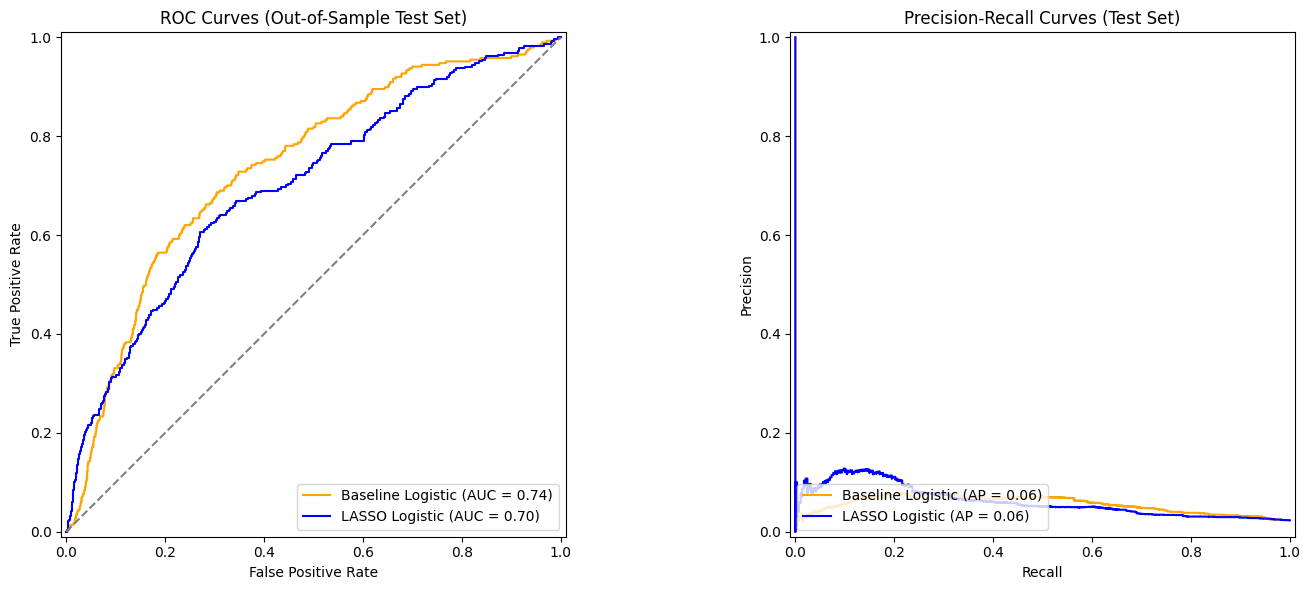

In [9]:
# Plot Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curves
RocCurveDisplay.from_predictions(y_test, y_test_pred_base, ax=ax1, name='Baseline Logistic', color='orange')
RocCurveDisplay.from_predictions(y_test, y_test_pred_lasso, ax=ax1, name='LASSO Logistic', color='blue')
ax1.plot([0, 1], [0, 1], linestyle='--', color='grey')
ax1.set_title('ROC Curves (Out-of-Sample Test Set)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

# PR Curves
PrecisionRecallDisplay.from_predictions(y_test, y_test_pred_base, ax=ax2, name='Baseline Logistic', color='orange')
PrecisionRecallDisplay.from_predictions(y_test, y_test_pred_lasso, ax=ax2, name='LASSO Logistic', color='blue')
ax2.set_title('Precision-Recall Curves (Test Set)')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')

plt.tight_layout()
plt.show()

## **7. Top-Risk Bucket Recall Analysis**
In credit risk practice, models are used to triage or screen customers. Lenders do not focus on overall accuracy; instead, they want to know **how many bankruptcies can be caught by flagging the riskiest 5% or 10% of firms**. Here we calculate the percentage of total bankruptcies captured in these top-risk buckets.

In [10]:
def evaluate_risk_buckets(y_true, y_pred, model_name):
    eval_df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    eval_df = eval_df.sort_values(by='y_pred', ascending=False).reset_index(drop=True)
    
    total_bankruptcies = eval_df['y_true'].sum()
    n_obs = len(eval_df)
    
    results = []
    for pct in [5, 10, 20]:
        cutoff = int(n_obs * (pct / 100))
        bucket_bankruptcies = eval_df.loc[:cutoff, 'y_true'].sum()
        recall = bucket_bankruptcies / total_bankruptcies
        results.append({
            'Model': model_name,
            'Bucket': f'Top {pct}% Riskiest',
            'Bankruptcies Captured': bucket_bankruptcies,
            'Total Bankruptcies': total_bankruptcies,
            'Recall (%)': recall * 100
        })
    return pd.DataFrame(results)
base_buckets = evaluate_risk_buckets(y_test, y_test_pred_base, 'Baseline Model')
lasso_buckets = evaluate_risk_buckets(y_test, y_test_pred_lasso, 'LASSO Model')
display(pd.concat([base_buckets, lasso_buckets]).reset_index(drop=True))

,Model,Bucket,Bankruptcies Captured,Total Bankruptcies,Recall (%)
0,Baseline Model,Top 5% Riskiest,41,287,14.285714
1,Baseline Model,Top 10% Riskiest,91,287,31.707317
2,Baseline Model,Top 20% Riskiest,162,287,56.445993
3,LASSO Model,Top 5% Riskiest,62,287,21.602787
4,LASSO Model,Top 10% Riskiest,90,287,31.358885
5,LASSO Model,Top 20% Riskiest,132,287,45.993031


### **Analysis and Takeaways**
1. **Baseline Model Performance**: The baseline 6-variable model yields a strong **0.737 Test ROC-AUC** and captures **31.71%** of all bankruptcies in the top 10% risk bucket.
2. **LASSO Model Performance**: While LASSO has a slightly lower Test ROC-AUC of **0.699**, it excels in the extreme risk screening. Its Top 5% risk bucket captures **21.60%** of all bankruptcies compared to only **14.29%** for the baseline model.
3. **Practical Value**: Flagging the top 10% riskiest firms enables a credit analyst to capture nearly **32% of all defaults** in the next fiscal year, reducing the review pool by 90%.